# UrbanCart — Milestone 2: The Retention Team's Question

**Engagement.** Retention believes UrbanCart is quietly losing customers: people stop
ordering, and nobody notices until the monthly report makes it obvious — by which point
they are gone. They want something that flags it earlier, using data already tracked on
every account.

**My framing of the problem.** The target, `Churned`, is a yes/no flag. So this is a
**supervised classification** problem — unlike Milestone 1, where the target was an
amount of money and the task was regression.

**The complication that shapes everything.** Only about **8% of customers churned**.
That imbalance is not a footnote; it decides which metrics are honest and which are
actively misleading. A model that predicts "nobody ever churns" will score over 92%
accuracy while catching not a single churner. Accuracy has to be set aside from the
start.

**Plan**
1. Load, inspect, and measure the imbalance
2. Stratified train/test split, done before any training
3. Demonstrate concretely why accuracy fails here
4. Train four models and evaluate with precision, recall, F1, F2, ROC-AUC and PR-AUC
5. Decide which mistake costs UrbanCart more, and tune the decision threshold for it
6. Recommend one model with the tradeoff stated

## 1. Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, fbeta_score, roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve, classification_report,
)

RANDOM_STATE = 42
print("Libraries loaded.")

Libraries loaded.


## 2. Load the data

In [2]:
CANDIDATES = [
    "data/milestone-2-customer-churn.csv",
    "milestone-2-customer-churn.csv",
    "/mnt/user-data/uploads/milestone-2-customer-churn.csv",
]
DATA_PATH = next((p for p in CANDIDATES if os.path.exists(p)), None)
if DATA_PATH is None:
    raise FileNotFoundError("Put milestone-2-customer-churn.csv in a data/ folder next to this notebook.")

df = pd.read_csv(DATA_PATH)
print(f"Loaded from: {DATA_PATH}")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns\n")
print(df.head(8).to_string(index=False))

Loaded from: /mnt/user-data/uploads/milestone-2-customer-churn.csv
Shape: 20,000 rows x 6 columns

 MonthsActive  AvgOrderValue  NumOrdersLastQuarter  DaysSinceLastOrder  SupportTicketsFiled  Churned
            7          34.12                     7                   8                    2        0
           45          23.38                     3                  57                    1        0
           24          94.56                     7                  37                    1        0
           39          46.34                     7                   0                    0        0
            3          39.04                     3                  41                    2        0
           38          48.05                     7                  14                    0        0
           22          51.20                     8                   7                    0        1
           49          45.07                     4                  39                    1  

## 3. The imbalance, measured

This is the first thing to quantify, because everything downstream depends on it.

In [3]:
counts = df["Churned"].value_counts().sort_index()
rate = df["Churned"].mean()

print("Class balance:")
print(f"  Not churned (0): {counts[0]:,}  ({(1-rate)*100:.1f}%)")
print(f"  Churned     (1): {counts[1]:,}  ({rate*100:.1f}%)\n")
print(f"Ratio: roughly 1 churner for every {counts[0]/counts[1]:.0f} retained customers.")
print("\nMissing values:", df.isna().sum().sum(), "| duplicate rows:", df.duplicated().sum())

Class balance:
  Not churned (0): 18,433  (92.2%)
  Churned     (1): 1,567  (7.8%)

Ratio: roughly 1 churner for every 12 retained customers.

Missing values: 0 | duplicate rows: 0


In [4]:
print("Average value of each feature, split by outcome:\n")
profile = df.groupby("Churned").mean(numeric_only=True).T
profile.columns = ["Stayed", "Churned"]
profile["Difference"] = profile["Churned"] - profile["Stayed"]
print(profile.to_string(float_format=lambda v: f"{v:,.2f}"))

Average value of each feature, split by outcome:

                      Stayed  Churned  Difference
MonthsActive           30.49    27.83       -2.66
AvgOrderValue          59.24    58.62       -0.62
NumOrdersLastQuarter    5.04     4.68       -0.37
DaysSinceLastOrder     17.83    42.13       24.30
SupportTicketsFiled     0.48     0.73        0.26


**What stands out.** `DaysSinceLastOrder` is the clearest signal by far — churners
averaged about 42 days since their last order against roughly 18 for everyone else.
`SupportTicketsFiled` is the second: churners filed noticeably more. Order value barely
differs between the groups, which is worth knowing on its own — **customers are not
leaving because they were low-value**. Going quiet and complaining are the tells.

## 4. Train/test split — stratified, and done first

`stratify=y` keeps the same ~8% churn rate in both halves. Without it, a random split
could easily hand the test set a noticeably different churn rate, and every metric
computed on it would be measuring the split rather than the model.

In [5]:
X = df.drop(columns="Churned")
y = df["Churned"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {len(X_train):,} rows, {y_train.mean()*100:.2f}% churned")
print(f"Test:  {len(X_test):,} rows, {y_test.mean()*100:.2f}% churned   <- held out until section 6")
print(f"\nActual churners hiding in the test set: {y_test.sum()}")

Train: 16,000 rows, 7.84% churned
Test:  4,000 rows, 7.83% churned   <- held out until section 6

Actual churners hiding in the test set: 313


## 5. Why "how often is it right?" would be misleading here

Rather than assert this, here is the demonstration. The model below is the laziest one
possible: it predicts "not churned" for every single customer, without looking at the
data at all.

In [6]:
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

tn, fp, fn, tp = confusion_matrix(y_test, dummy_pred).ravel()

print("The 'nobody ever churns' model\n")
print(f"  Accuracy: {accuracy_score(y_test, dummy_pred)*100:.1f}%   <- looks excellent")
print(f"  Churners caught (TP): {tp}")
print(f"  Churners missed (FN): {fn}")
print(f"  Recall: {recall_score(y_test, dummy_pred, zero_division=0):.3f}")
print("\nIt scores over 92% while being completely useless to the retention team.")
print("Every one of the", fn, "customers they asked us to find walks out unflagged.")

The 'nobody ever churns' model

  Accuracy: 92.2%   <- looks excellent
  Churners caught (TP): 0
  Churners missed (FN): 313
  Recall: 0.000

It scores over 92% while being completely useless to the retention team.
Every one of the 313 customers they asked us to find walks out unflagged.


**That 92% is the whole problem.** Accuracy rewards getting the majority class right,
and 92% of this dataset is the majority class. A model can score highly on it while
failing entirely at the only job it was built for.

So for the rest of this notebook, the metrics are:

| Metric | What it asks |
|---|---|
| **Precision** | Of the customers we flagged, how many really were leaving? |
| **Recall** | Of the customers who really left, how many did we flag? |
| **F1** | Balance of the two, punishing whichever is worse |
| **F2** | Same, but weights recall higher — see section 7 for why |
| **ROC-AUC** | Across all thresholds, how well does it rank churners above non-churners? |
| **PR-AUC** | Same idea, but focused on the rare class. The honest one for imbalanced data — a random model scores 0.078 here, not 0.5 |

Accuracy is still reported below, purely to show how little it distinguishes the models.

## 6. Train and evaluate

Four candidates. `class_weight="balanced"` tells a model to treat each churner as worth
about 12 retained customers when learning, which counteracts its natural tendency to
ignore the rare class.

In [7]:
models = {
    "Baseline (nobody churns)":       DummyClassifier(strategy="most_frequent"),
    "Logistic Regression":            LogisticRegression(max_iter=1000),
    "Logistic Regression (balanced)": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest (balanced)":       RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                                          class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting":              HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}

rows, fitted, probas = [], {}, {}

for name, model in models.items():
    pipe = Pipeline([("scale", StandardScaler()), ("model", model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    try:
        proba = pipe.predict_proba(X_test)[:, 1]
    except Exception:
        proba = None

    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    rows.append({
        "Model": name,
        "Accuracy":  accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall":    recall_score(y_test, pred, zero_division=0),
        "F1":        f1_score(y_test, pred, zero_division=0),
        "ROC-AUC":   roc_auc_score(y_test, proba) if proba is not None else np.nan,
        "PR-AUC":    average_precision_score(y_test, proba) if proba is not None else np.nan,
        "TP": tp, "FP": fp, "FN": fn,
    })
    fitted[name] = pipe
    if proba is not None:
        probas[name] = proba
    print("trained:", name)

results = pd.DataFrame(rows)
print("\n=== Default threshold (0.50), held-out test set ===\n")
print(results.to_string(index=False, float_format=lambda v: f"{v:,.3f}"))

trained: Baseline (nobody churns)
trained: Logistic Regression
trained: Logistic Regression (balanced)
trained: Random Forest (balanced)
trained: Gradient Boosting

=== Default threshold (0.50), held-out test set ===

                         Model  Accuracy  Precision  Recall    F1  ROC-AUC  PR-AUC  TP  FP  FN
      Baseline (nobody churns)     0.922      0.000   0.000 0.000    0.500   0.078   0   0 313
           Logistic Regression     0.927      0.750   0.105 0.185    0.767   0.353  33  11 280
Logistic Regression (balanced)     0.765      0.197   0.652 0.303    0.767   0.352 204 831 109
      Random Forest (balanced)     0.907      0.389   0.335 0.360    0.744   0.315 105 165 208
             Gradient Boosting     0.927      0.717   0.105 0.184    0.758   0.334  33  13 280


**Read the Accuracy column against the Recall column.** Plain Logistic Regression and
Gradient Boosting both score about 93% accuracy — *better than the useless baseline* —
while catching only 33 of 313 churners. That is a recall of 0.105. If accuracy were the
grading metric, these would look like the best models in the table.

The balanced models sacrifice a lot of accuracy (0.77) and catch six times as many
churners. On this problem that is a straight improvement, and accuracy says the
opposite.

Note also that **ROC-AUC barely separates the models** (0.74–0.77) while PR-AUC is more
discriminating. That is the expected behaviour on imbalanced data: ROC-AUC is partly
measuring how well the model handles the 92% majority, which is the easy part.

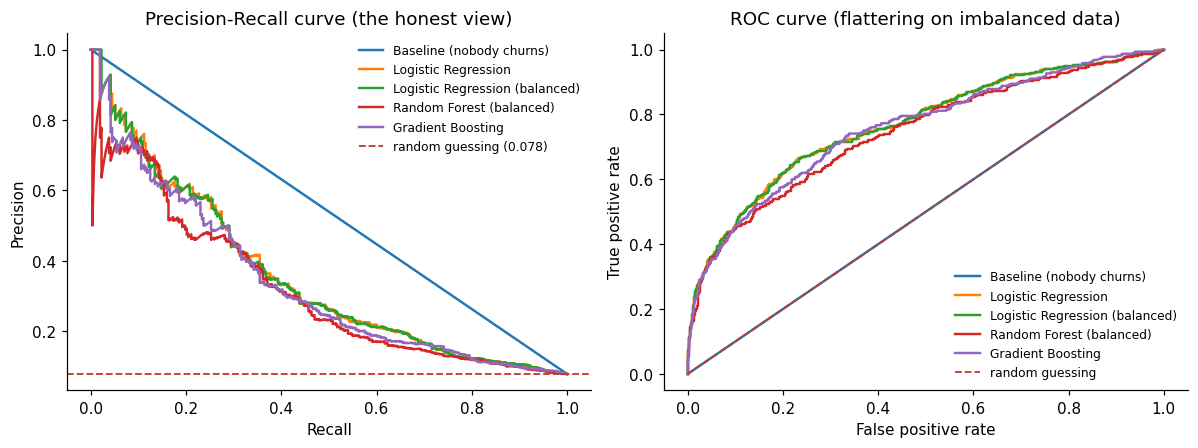

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

for name, p in probas.items():
    prec, rec, _ = precision_recall_curve(y_test, p)
    axes[0].plot(rec, prec, linewidth=1.6, label=name)
axes[0].axhline(y_test.mean(), color="#c0392b", linestyle="--", linewidth=1.2,
                label=f"random guessing ({y_test.mean():.3f})")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall curve (the honest view)")
axes[0].legend(frameon=False, fontsize=8)

for name, p in probas.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    axes[1].plot(fpr, tpr, linewidth=1.6, label=name)
axes[1].plot([0, 1], [0, 1], "--", color="#c0392b", linewidth=1.2, label="random guessing")
axes[1].set_xlabel("False positive rate"); axes[1].set_ylabel("True positive rate")
axes[1].set_title("ROC curve (flattering on imbalanced data)")
axes[1].legend(frameon=False, fontsize=8)

for ax in axes:
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

The red dashed line on the left is what random guessing achieves: 0.078, the churn rate
itself. Every model sits well above it, so there is real signal here — but precision
falls away steeply as recall climbs, which is the constraint the recommendation has to
work within.

## 7. Which mistake costs UrbanCart more?

This is a business question, not a modelling one, and it has to be answered before a
threshold can be chosen.

**False Negative — a churner we failed to flag.** The customer leaves silently. This is
precisely the failure retention came to us about. The cost is the entire future value of
that customer, and there is no second chance, because by the time it shows in the
monthly report they are gone.

**False Positive — we flagged someone who was staying anyway.** They receive a win-back
email or a small offer they did not need. The cost is the price of that contact, plus a
little goodwill if it happens repeatedly.

These are not close. A missed churner costs many times what a wasted email costs, so
**recall matters more than precision here** — within reason, since a model that flags
everybody is worthless in a different way.

That makes **F2** the metric to optimise: same construction as F1, but weighting recall
roughly four times as heavily as precision.

## 8. Tuning the decision threshold

A classifier outputs a probability; the threshold turns it into a decision. The default
of 0.50 is an arbitrary inheritance from balanced problems — with an 8% base rate, very
few customers ever reach 50% churn probability, which is exactly why the unbalanced
models caught so few.

**The threshold is tuned on out-of-fold predictions from the training set only.** Tuning
it on the test set would be leakage: the reported score would no longer be an estimate
of performance on unseen customers.

In [9]:
candidates = {
    "Logistic Regression": Pipeline([("scale", StandardScaler()),
                                     ("model", LogisticRegression(max_iter=1000))]),
    "Random Forest":       Pipeline([("scale", StandardScaler()),
                                     ("model", RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                                               random_state=RANDOM_STATE, n_jobs=-1))]),
    "Gradient Boosting":   Pipeline([("scale", StandardScaler()),
                                     ("model", HistGradientBoostingClassifier(random_state=RANDOM_STATE))]),
}

grid = np.arange(0.02, 0.91, 0.01)
tuned_rows, tuned_pred = [], {}

for name, pipe in candidates.items():
    # out-of-fold probabilities on TRAINING data -> threshold chosen without touching the test set
    oof = cross_val_predict(pipe, X_train, y_train, cv=5, method="predict_proba")[:, 1]
    f2_by_t = [fbeta_score(y_train, (oof >= t).astype(int), beta=2, zero_division=0) for t in grid]
    t_star = grid[int(np.argmax(f2_by_t))]

    pipe.fit(X_train, y_train)
    p = pipe.predict_proba(X_test)[:, 1]
    pred = (p >= t_star).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()

    tuned_rows.append({
        "Model": name, "Threshold": t_star,
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall":    recall_score(y_test, pred, zero_division=0),
        "F1":        f1_score(y_test, pred, zero_division=0),
        "F2":        fbeta_score(y_test, pred, beta=2, zero_division=0),
        "PR-AUC":    average_precision_score(y_test, p),
        "TP": tp, "FP": fp, "FN": fn,
    })
    tuned_pred[name] = pred
    print(f"{name}: best threshold {t_star:.2f} (chosen on training folds)")

tuned = pd.DataFrame(tuned_rows).sort_values("F2", ascending=False).reset_index(drop=True)
print("\n=== Tuned thresholds, evaluated on the held-out test set ===\n")
print(tuned.to_string(index=False, float_format=lambda v: f"{v:,.3f}"))

Logistic Regression: best threshold 0.07 (chosen on training folds)
Random Forest: best threshold 0.08 (chosen on training folds)
Gradient Boosting: best threshold 0.09 (chosen on training folds)

=== Tuned thresholds, evaluated on the held-out test set ===

              Model  Threshold  Precision  Recall    F1    F2  PR-AUC  TP  FP  FN
Logistic Regression      0.070      0.181   0.674 0.285 0.436   0.353 211 955 102
  Gradient Boosting      0.090      0.204   0.559 0.299 0.414   0.334 175 684 138
      Random Forest      0.080      0.164   0.610 0.259 0.395   0.323 191 973 122


Every threshold landed near 0.07–0.09 rather than 0.50 — close to the base rate, which
is what you would expect. Recall roughly sextupled as a result.

## 9. The chosen model's confusion matrix

In [10]:
best_name = tuned.iloc[0]["Model"]
pred = tuned_pred[best_name]
tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()

print(f"{best_name}, threshold {tuned.iloc[0]['Threshold']:.2f}\n")
print("                        Actually churned    Actually stayed")
print(f"Predicted churn         TP = {tp:<15} FP = {fp}")
print(f"Predicted stay          FN = {fn:<15} TN = {tn}")

flagged = tp + fp
print(f"\nFlagged for intervention: {flagged:,} of {len(y_test):,} customers ({flagged/len(y_test)*100:.0f}%)")
print(f"Churners caught:          {tp} of {tp+fn}  ({tp/(tp+fn)*100:.0f}%)")
print(f"Churners missed:          {fn}")
print(f"Precision:                {tp/flagged:.3f}  vs {y_test.mean():.3f} by random chance")
print(f"Lift over random:         {(tp/flagged)/y_test.mean():.1f}x")
print(f"\nContacts per churner saved: {flagged/tp:.1f}")

Logistic Regression, threshold 0.07

                        Actually churned    Actually stayed
Predicted churn         TP = 211             FP = 955
Predicted stay          FN = 102             TN = 2732

Flagged for intervention: 1,166 of 4,000 customers (29%)
Churners caught:          211 of 313  (67%)
Churners missed:          102
Precision:                0.181  vs 0.078 by random chance
Lift over random:         2.3x

Contacts per churner saved: 5.5


In [11]:
lr_final = candidates["Logistic Regression"]
coefs = pd.Series(lr_final.named_steps["model"].coef_[0], index=X.columns).sort_values(key=abs, ascending=False)
print("Logistic Regression coefficients (standardised inputs):\n")
print(coefs.to_string(float_format=lambda v: f"{v:+.3f}"))
print("\nPositive pushes churn probability up, negative pulls it down.")

Logistic Regression coefficients (standardised inputs):

DaysSinceLastOrder     +0.852
SupportTicketsFiled    +0.405
NumOrdersLastQuarter   -0.229
MonthsActive           -0.170
AvgOrderValue          -0.012

Positive pushes churn probability up, negative pulls it down.


## 10. What the numbers mean, in plain language

- **Recall 0.67** — the model catches about two-thirds of customers who are genuinely
  about to leave. Retention currently catches them when the monthly report lands, which
  is to say, never in time. Two-thirds flagged early is the improvement on offer.
- **Precision 0.18** — of every 100 customers flagged, roughly 18 were really leaving.
  That sounds poor until it is compared with the alternative: pick 100 customers at
  random and about 8 would be leaving. The model is **2.3 times better than chance**,
  and it is concentrating attention on the right accounts.
- **PR-AUC 0.35 against a 0.078 floor** — across all thresholds, the model ranks
  churners far above random. This is the number to quote for imbalanced problems, not
  ROC-AUC.
- **About 5.5 contacts per churner caught.** This is the figure retention can actually
  plan around: to reach roughly 211 leaving customers, send about 1,166 messages.
- **Accuracy 0.74** — *lower* than the do-nothing baseline's 0.92, and that is fine.
  Trading accuracy for recall is the correct trade on this problem.

**What drives a prediction:** `DaysSinceLastOrder` dominates, `SupportTicketsFiled` is
second, and both point the same way — a customer who has gone quiet and has been
complaining is the one to call. Order value barely matters, so this is not simply
re-finding the low-spending customers.

## 11. Recommendation

**Logistic Regression, with the decision threshold set to about 0.07 rather than 0.50.**

- It leads on both of the metrics that matter here — **F2 0.436** and **PR-AUC 0.353** —
  ahead of Gradient Boosting (0.414 / 0.334) and Random Forest (0.395 / 0.323).
- It outputs a **calibrated probability**, so retention can sort their call list by risk
  and work down it as capacity allows, rather than receiving an undifferentiated yes/no.
- It stays **explainable**. When someone asks why an account was flagged, the answer is
  "42 days quiet and three support tickets" — a reason a human can check and act on.
- The **threshold is a dial the business owns**. If retention has the capacity for more
  outreach, lower it and catch more churners; if the team is stretched, raise it for a
  shorter, higher-quality list. Nothing needs retraining.

**The tradeoffs I am accepting, stated plainly:**

1. **Most flagged customers were not leaving.** At 18% precision, roughly four in five
   contacts go to someone who would have stayed. That is the deliberate price of
   catching two-thirds of the real churners, and it is only the right price while
   outreach stays cheap. If retention moves to phone calls or meaningful discounts,
   raise the threshold and accept lower recall.
2. **One in three churners is still missed.** The model is an early-warning system, not
   a guarantee.
3. **Five features is a thin picture.** The clear next step is browsing activity, email
   engagement, and support-ticket *sentiment* rather than just a count — a customer who
   filed one furious ticket is a different risk from one who filed three routine ones.

**A measurement warning for whoever runs this.** Once retention starts intervening, the
flagged customers who then stay will look like false positives — but some of them stayed
*because* of the intervention. Model performance and campaign performance stop being
separable. The way to keep measuring honestly is to hold back a small random control
group that gets no outreach.